In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE    = '/content/drive/MyDrive/lab2'
os.makedirs(DRIVE_BASE, exist_ok=True)

ZIP_PATH      = f'{DRIVE_BASE}/ucf101-action-recognition.zip'
META_PATH     = f'{DRIVE_BASE}/HowTo100M_v1.csv'
HOWTO_ZIP     = f'{DRIVE_BASE}/HowTo100M.zip'
TRAIN_EMB     = f'{DRIVE_BASE}/ucf_train_emb_norm.npz'
TEST_EMB      = f'{DRIVE_BASE}/ucf_test_emb_norm.npz'
WEIGHTS_PATH  = '/content/s3d_howto100m.pth'
WORD_VEC_PATH = '/content/s3d_dict.npy'

print('Drive подключён')
print('Содержимое lab2:')
for item in sorted(os.listdir(DRIVE_BASE)):
    full = os.path.join(DRIVE_BASE, item)
    if os.path.isdir(full):
        print(f'  [папка] {item}/')
    else:
        print(f'  [файл]  {item} ({os.path.getsize(full)/1e6:.0f} МБ)')

Mounted at /content/drive
Drive подключён
Содержимое lab2:
  [файл]  HowTo100M.zip (1993 МБ)
  [файл]  HowTo100M_v1.csv (65 МБ)
  [файл]  README.txt (0 МБ)
  [файл]  all_metrics.png (0 МБ)
  [файл]  caption.json (6305 МБ)
  [файл]  cm_5-shot_cm.png (0 МБ)
  [файл]  cm_linear_probe_cm.png (0 МБ)
  [файл]  cm_zero-shot_cm.png (0 МБ)
  [файл]  domain_gap.png (0 МБ)
  [файл]  metrics_comparison.png (0 МБ)
  [файл]  s3d_features_readme.txt (0 МБ)
  [файл]  task_ids.csv (4 МБ)
  [папка] test/
  [файл]  test.csv (0 МБ)
  [папка] train/
  [папка] ucfTrainTestlist/
  [файл]  ucf_test_emb_norm.npz (4 МБ)
  [файл]  ucf_train_emb_norm.npz (21 МБ)


In [2]:
!pip install av scikit-learn -q

import os, sys
if not os.path.exists('/content/S3D_HowTo100M'):
    !git clone https://github.com/antoine77340/S3D_HowTo100M.git /content/S3D_HowTo100M -q
    print('S3D репозиторий скачан')
else:
    print('S3D репозиторий уже есть')

sys.path.insert(0, '/content/S3D_HowTo100M')

import av
print(f'av версия: {av.__version__}')
print('Зависимости готовы')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 52.5 MB/s eta 0:00:00
S3D репозиторий скачан
av версия: 17.0.1
Зависимости готовы


In [7]:
import os, io, time, random, warnings, re, types, zipfile, urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, top_k_accuracy_score
)
import av
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU не найден. Зайди в: Среда выполнения -> Сменить среду -> T4 GPU')

NUM_FRAMES  = 32
FRAME_SIZE  = 224
EMBED_DIM   = 512
BATCH_SIZE  = 4
NUM_CLASSES = 101

print(f'Устройство: {DEVICE}')

GPU: Tesla T4
Устройство: cuda


In [9]:
from s3dg import S3D

if not os.path.exists(WEIGHTS_PATH):
    print('Скачиваем веса S3D (~90 МБ)...')
    urllib.request.urlretrieve(
        'https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/s3d_howto100m.pth',
        WEIGHTS_PATH
    )

if not os.path.exists(WORD_VEC_PATH):
    print('Скачиваем словарь (~6 МБ)...')
    urllib.request.urlretrieve(
        'https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/s3d_dict.npy',
        WORD_VEC_PATH
    )

model = S3D(WORD_VEC_PATH, EMBED_DIM)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu'))
model = model.to(DEVICE).eval()

for p in model.parameters():
    p.requires_grad = False

# Патч 1: _zero_pad_tensor_token создаёт zero без device
def _zero_pad_fixed(self, tensor, size):
    if len(tensor) >= size:
        return tensor[:size]
    zero = torch.zeros(size - len(tensor), dtype=torch.long, device=tensor.device)
    return torch.cat((tensor, zero), dim=0)

# Патч 2: _words_to_token создаёт LongTensor без device
def _words_to_token_fixed(self, words):
    device = next(self.parameters()).device
    words  = [self.word_to_token[w] for w in words if w in self.word_to_token]
    if words:
        return self._zero_pad_tensor_token(
            torch.tensor(words, dtype=torch.long, device=device), self.max_words
        )
    return torch.zeros(self.max_words, dtype=torch.long, device=device)

# Патч 3: _words_to_ids делает stack на CPU
def _words_to_ids_fixed(self, x):
    device  = next(self.parameters()).device
    split_x = [self._words_to_token(self._split_text(s.lower())) for s in x]
    return torch.stack(split_x, dim=0).to(device)

model.text_module._zero_pad_tensor_token = types.MethodType(_zero_pad_fixed,       model.text_module)
model.text_module._words_to_token        = types.MethodType(_words_to_token_fixed, model.text_module)
model.text_module._words_to_ids          = types.MethodType(_words_to_ids_fixed,   model.text_module)

# Проверка
with torch.no_grad():
    dummy    = torch.rand(2, 3, 32, 224, 224).to(DEVICE)
    out      = model(dummy)
    text_out = model.text_module(['playing football', 'swimming'])
    print('S3D загружена')
    print(f'  video_embedding: {out["video_embedding"].shape}')
    print(f'  text_embedding:  {text_out["text_embedding"].shape}')
    print(f'  device:          {text_out["text_embedding"].device}')
    raw_norm = out['video_embedding'].norm().item()
    print(f'  норма video (до L2-норм.): {raw_norm:.4f}  -- S3D не нормализует, делаем сами')

Скачиваем веса S3D (~90 МБ)...
Скачиваем словарь (~6 МБ)...
S3D загружена
  video_embedding: torch.Size([2, 512])
  text_embedding:  torch.Size([2, 512])
  device:          cuda:0
  норма video (до L2-норм.): 0.3660  -- S3D не нормализует, делаем сами


In [10]:
if not os.path.exists(META_PATH):
    if not os.path.exists(HOWTO_ZIP) or os.path.getsize(HOWTO_ZIP) < 1e6:
        print('Скачиваем метаданные HowTo100M (~2 ГБ, 5-10 мин)...')
        urllib.request.urlretrieve(
            'https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/HowTo100M.zip',
            HOWTO_ZIP
        )
        print(f'Скачано: {os.path.getsize(HOWTO_ZIP)/1e6:.0f} МБ')
    print('Распаковываем...')
    with zipfile.ZipFile(HOWTO_ZIP, 'r') as z:
        z.extractall(DRIVE_BASE)
    print('Готово')
else:
    print('Метаданные уже есть на Drive')

meta        = pd.read_csv(META_PATH)
sports_meta = meta[meta['category_1'].str.contains('Sport', case=False, na=False)].copy()

SPORTS_CLASSES     = sports_meta['category_2'].value_counts().index.tolist()
NUM_SPORTS_CLASSES = len(SPORTS_CLASSES)
CATEGORY_COL       = 'category_2'
sports_meta['label'] = sports_meta[CATEGORY_COL].map(
    {c: i for i, c in enumerate(SPORTS_CLASSES)}
)

print(f'Всего видео HowTo100M: {len(meta):,}')
print(f'Sports видео:          {len(sports_meta):,}')
print(f'Подкатегории ({NUM_SPORTS_CLASSES} классов):')
print(sports_meta[CATEGORY_COL].value_counts())

Метаданные уже есть на Drive
Всего видео HowTo100M: 1,238,911
Sports видео:          15,976
Подкатегории (4 классов):
category_2
Outdoor Recreation    8853
Individual Sports     4131
Team Sports           2595
Personal Fitness       397
Name: count, dtype: int64


In [11]:
@torch.no_grad()
def get_sports_class_embeddings(sports_classes, model):
    """Вычисляет L2-нормализованные текстовые эмбеддинги 4 подкатегорий Sports."""
    templates_per_class = {
        'Outdoor Recreation': [
            'outdoor recreation sports',
            'hiking camping cycling outdoor',
            'outdoor activities nature sports',
            'rock climbing kayaking skiing outdoor',
            'how to do outdoor sports',
            'outdoor recreation tutorial',
        ],
        'Individual Sports': [
            'individual sports training',
            'tennis swimming gymnastics martial arts',
            'how to play individual sport',
            'solo sport training tutorial',
            'individual athlete training',
            'learning individual sports skills',
        ],
        'Team Sports': [
            'team sports playing',
            'football basketball soccer volleyball team',
            'how to play team sport',
            'team sport training tutorial',
            'playing team sports with others',
            'team sport skills and drills',
        ],
        'Personal Fitness': [
            'personal fitness workout',
            'exercise training fitness gym',
            'how to workout fitness training',
            'personal fitness routine tutorial',
            'strength cardio fitness exercise',
            'home workout fitness training',
        ],
    }
    class_embeddings = []
    for cls_name in sports_classes:
        texts = templates_per_class.get(cls_name, [cls_name])
        out   = model.text_module(texts)
        embs  = out['text_embedding']
        # text_module уже нормализует — усредняем и нормализуем снова
        avg   = F.normalize(embs.mean(0), dim=0)
        class_embeddings.append(avg.cpu())
        print(f'  {cls_name}: {len(texts)} шаблонов')
    return torch.stack(class_embeddings)


print('Вычисляем эмбеддинги подкатегорий HowTo100M Sports...')
sports_class_embs = get_sports_class_embeddings(SPORTS_CLASSES, model)
print(f'Sports class embeddings: {sports_class_embs.shape}')

Вычисляем эмбеддинги подкатегорий HowTo100M Sports...
  Outdoor Recreation: 6 шаблонов
  Individual Sports: 6 шаблонов
  Team Sports: 6 шаблонов
  Personal Fitness: 6 шаблонов
Sports class embeddings: torch.Size([4, 512])


In [12]:
@torch.no_grad()
def build_training_embeddings(sports_classes, model):
    """Строим обучающую выборку из текстовых описаний каждого класса."""
    all_embs, all_labels = [], []
    base_templates = [
        '{}', 'how to {}', 'tutorial on {}', 'learn {}',
        '{} sports training', '{} skills and techniques',
        '{} exercise', '{} workout', '{} practice',
        'playing {}', 'doing {}', 'beginner guide to {}',
        'advanced {} training', '{} for beginners',
    ]
    for label, cls_name in enumerate(sports_classes):
        readable = cls_name.lower()
        texts    = [t.format(readable) for t in base_templates]
        for i in range(0, len(texts), 32):
            out  = model.text_module(texts[i:i+32])
            embs = out['text_embedding'].cpu()
            all_embs.append(embs)
            all_labels.extend([label] * len(texts[i:i+32]))
        print(f'  Класс {label}: {cls_name} -- {len(texts)} описаний')
    embs   = torch.cat(all_embs, dim=0)
    labels = torch.tensor(all_labels, dtype=torch.long)
    print(f'Итого: {len(embs)} обучающих примеров')
    return embs, labels


print('Строим обучающую выборку...')
howto_embs, howto_labels = build_training_embeddings(SPORTS_CLASSES, model)

train_ds = TensorDataset(howto_embs, howto_labels)
train_ld = DataLoader(train_ds, batch_size=64, shuffle=True)

sports_classifier = nn.Linear(EMBED_DIM, NUM_SPORTS_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(sports_classifier.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

print('Обучаем классификатор на HowTo100M Sports...')
for epoch in range(1, 101):
    sports_classifier.train()
    total_loss, correct, total = 0.0, 0, 0
    for embs, labels in train_ld:
        embs, labels = embs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = sports_classifier(embs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    scheduler.step()
    if epoch % 20 == 0:
        print(f'  Эпоха {epoch:3d}/100 | Loss: {total_loss/len(train_ld):.4f} | Acc: {correct/total:.3f}')

print('Классификатор обучен')

Строим обучающую выборку...
  Класс 0: Outdoor Recreation -- 14 описаний
  Класс 1: Individual Sports -- 14 описаний
  Класс 2: Team Sports -- 14 описаний
  Класс 3: Personal Fitness -- 14 описаний
Итого: 56 обучающих примеров
Обучаем классификатор на HowTo100M Sports...
  Эпоха  20/100 | Loss: 0.0019 | Acc: 1.000
  Эпоха  40/100 | Loss: 0.0005 | Acc: 1.000
  Эпоха  60/100 | Loss: 0.0004 | Acc: 1.000
  Эпоха  80/100 | Loss: 0.0004 | Acc: 1.000
  Эпоха 100/100 | Loss: 0.0004 | Acc: 1.000
Классификатор обучен


In [13]:
if not os.path.exists('/root/.kaggle/kaggle.json'):
    from google.colab import files
    print('Загрузи kaggle.json:')
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print('Kaggle настроен')
else:
    print('Kaggle уже настроен')

if not os.path.exists(ZIP_PATH) or os.path.getsize(ZIP_PATH) < 1e6:
    print('Скачиваем UCF-101 на Drive (~7 ГБ, ~2 мин)...')
    !kaggle datasets download \
        -d matthewjansen/ucf101-action-recognition \
        -p {DRIVE_BASE}
    print('UCF-101 скачан')
else:
    print(f'UCF-101 уже есть на Drive ({os.path.getsize(ZIP_PATH)/1e9:.1f} ГБ)')

print('Проверяем структуру zip...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    names         = z.namelist()
    train_entries = [n for n in names if n.startswith('train/') and n.endswith('.avi')]
    test_entries  = [n for n in names if n.startswith('test/')  and n.endswith('.avi')]
    print(f'  Train видео: {len(train_entries)}')
    print(f'  Test видео:  {len(test_entries)}')

Загрузи kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle настроен
Скачиваем UCF-101 на Drive (~7 ГБ, ~2 мин)...
Dataset URL: https://www.kaggle.com/datasets/matthewjansen/ucf101-action-recognition
License(s): CC0-1.0
100% 6.53G/6.53G [01:10<00:00, 99.8MB/s]

UCF-101 скачан
Проверяем структуру zip...
  Train видео: 10055
  Test видео:  1723


In [14]:
print('Читаем структуру датасета из zip...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    all_entries   = z.namelist()
    train_entries = [n for n in all_entries
                     if n.startswith('train/') and n.endswith('.avi')]
    test_entries  = [n for n in all_entries
                     if n.startswith('test/')  and n.endswith('.avi')]

train_classes = sorted(set(e.split('/')[1] for e in train_entries))
test_classes  = sorted(set(e.split('/')[1] for e in test_entries))
ALL_CLASSES   = sorted(set(train_classes) | set(test_classes))
NUM_CLASSES   = len(ALL_CLASSES)
cls_to_idx    = {c: i for i, c in enumerate(ALL_CLASSES)}
CLASS_NAMES   = ALL_CLASSES

print(f'Классов: {NUM_CLASSES}')
print(f'Train видео: {len(train_entries)}')
print(f'Test видео:  {len(test_entries)}')

train_samples = [(e, cls_to_idx[e.split('/')[1]]) for e in train_entries]
test_samples  = [(e, cls_to_idx[e.split('/')[1]]) for e in test_entries]


def load_video_from_zip(zip_path, entry, num_frames=32, size=224):
    """
    Читает видео прямо из zip через io.BytesIO.
    Нормализация к [0, 1] как требует S3D.
    """
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            data = z.read(entry)
        container  = av.open(io.BytesIO(data))
        all_frames = []
        for frame in container.decode(video=0):
            img = frame.to_image().resize((size, size))
            all_frames.append(np.array(img))
        container.close()
        if not all_frames:
            return torch.zeros(3, num_frames, size, size)
        indices = np.linspace(0, len(all_frames) - 1, num_frames, dtype=int)
        frames  = [all_frames[i] for i in indices]
        while len(frames) < num_frames:
            frames.append(frames[-1])
        video = np.stack(frames[:num_frames]).astype(np.float32) / 255.0
        return torch.from_numpy(video).permute(3, 0, 1, 2)  # (3, T, H, W)
    except Exception:
        return torch.zeros(3, num_frames, size, size)


class UCF101ZipDataset(Dataset):
    """Dataset читающий видео прямо из zip."""
    def __init__(self, zip_path, samples, num_frames=32, size=224):
        self.zip_path   = zip_path
        self.samples    = samples
        self.num_frames = num_frames
        self.size       = size
        print(f'Dataset: {len(samples)} видео (читаем из zip)')

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        entry, label = self.samples[idx]
        return load_video_from_zip(self.zip_path, entry,
                                    self.num_frames, self.size), label


print('Создаём датасеты...')
train_dataset = UCF101ZipDataset(ZIP_PATH, train_samples, NUM_FRAMES, FRAME_SIZE)
test_dataset  = UCF101ZipDataset(ZIP_PATH, test_samples,  NUM_FRAMES, FRAME_SIZE)

# num_workers=0 -- zipfile не thread-safe
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print('Датасеты готовы')

Читаем структуру датасета из zip...
Классов: 101
Train видео: 10055
Test видео:  1723
Создаём датасеты...
Dataset: 10055 видео (читаем из zip)
Dataset: 1723 видео (читаем из zip)
Датасеты готовы


In [15]:
@torch.no_grad()
def extract_embeddings_normalized(model, loader, device, desc=''):
    """
    Извлекает video_embedding и применяет L2-нормализацию.
    S3D не нормализует выход -- делаем это явно.
    """
    model.eval()
    all_embs, all_labels = [], []
    total = len(loader)

    for i, (videos, labels) in enumerate(loader):
        videos = videos.float().to(device)
        out    = model(videos)
        emb    = out['video_embedding']
        # L2-нормализация: приводим норму к 1.0
        emb    = F.normalize(emb, dim=1)
        all_embs.append(emb.cpu().numpy())
        all_labels.append(labels.numpy())
        if (i + 1) % 200 == 0 or (i + 1) == total:
            print(f'  {desc}: {i+1}/{total} батчей')

    embs = np.concatenate(all_embs)
    labs = np.concatenate(all_labels)
    print(f'  Норма (среднее): {np.linalg.norm(embs, axis=1).mean():.4f}  (должна быть 1.0)')
    return embs, labs


if not os.path.exists(TRAIN_EMB):
    print('Извлекаем train эмбеддинги (~45-90 мин)...')
    t0 = time.time()
    train_emb, train_labels = extract_embeddings_normalized(
        model, train_loader, DEVICE, 'train')
    np.savez(TRAIN_EMB, embeddings=train_emb, labels=train_labels)
    print(f'Сохранено на Drive за {(time.time()-t0)/60:.1f} мин | форма: {train_emb.shape}')
else:
    d = np.load(TRAIN_EMB)
    train_emb, train_labels = d['embeddings'], d['labels']
    print(f'Train эмбеддинги загружены с Drive: {train_emb.shape}')
    print(f'Норма (среднее): {np.linalg.norm(train_emb, axis=1).mean():.4f}')

if not os.path.exists(TEST_EMB):
    print('Извлекаем test эмбеддинги...')
    t0 = time.time()
    test_emb, test_labels = extract_embeddings_normalized(
        model, test_loader, DEVICE, 'test')
    np.savez(TEST_EMB, embeddings=test_emb, labels=test_labels)
    print(f'Сохранено на Drive за {(time.time()-t0)/60:.1f} мин')
else:
    d = np.load(TEST_EMB)
    test_emb, test_labels = d['embeddings'], d['labels']
    print(f'Test эмбеддинги загружены с Drive: {test_emb.shape}')
    print(f'Норма (среднее): {np.linalg.norm(test_emb, axis=1).mean():.4f}')

Извлекаем train эмбеддинги (~45-90 мин)...
  train: 200/2514 батчей
  train: 400/2514 батчей
  train: 600/2514 батчей
  train: 800/2514 батчей
  train: 1000/2514 батчей
  train: 1200/2514 батчей
  train: 1400/2514 батчей
  train: 1600/2514 батчей
  train: 1800/2514 батчей
  train: 2000/2514 батчей
  train: 2200/2514 батчей
  train: 2400/2514 батчей
  train: 2514/2514 батчей
  Норма (среднее): 1.0000  (должна быть 1.0)
Сохранено на Drive за 123.6 мин | форма: (10055, 512)
Извлекаем test эмбеддинги...
  test: 200/431 батчей
  test: 400/431 батчей
  test: 431/431 батчей
  Норма (среднее): 1.0000  (должна быть 1.0)
Сохранено на Drive за 23.1 мин


In [16]:
def class_name_to_text(cls_name):
    """'ApplyEyeMakeup' -> 'apply eye makeup'"""
    return ' '.join(re.sub(r'([A-Z])', r' \1', cls_name).split()).lower()


TEMPLATES = [
    '{}', 'a video of {}', 'a person {}',
    'someone is {}', 'how to {}', 'tutorial on {}',
]


@torch.no_grad()
def get_ucf_text_embeddings(class_names, model, templates):
    """Вычисляет L2-нормализованные текстовые эмбеддинги всех классов UCF-101."""
    class_embs = []
    for cls_name in class_names:
        readable = class_name_to_text(cls_name)
        texts    = [t.format(readable) for t in templates]
        out      = model.text_module(texts)
        embs     = out['text_embedding']
        avg      = F.normalize(embs.mean(0), dim=0)
        class_embs.append(avg.cpu())
    return torch.stack(class_embs)


print('Вычисляем текстовые эмбеддинги классов UCF-101...')
ucf_text_embs = get_ucf_text_embeddings(CLASS_NAMES, model, TEMPLATES)
print(f'UCF text embeddings: {ucf_text_embs.shape}')
print(f'Норма (среднее): {ucf_text_embs.norm(dim=1).mean():.4f}')

Вычисляем текстовые эмбеддинги классов UCF-101...
UCF text embeddings: torch.Size([101, 512])
Норма (среднее): 1.0000


In [17]:
def compute_metrics(labels, preds, logits=None, k=5):
    acc         = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    m = {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}
    if logits is not None:
        try:
            m[f'top{k}_accuracy'] = top_k_accuracy_score(labels, logits, k=k)
        except Exception:
            pass
    return m


print('Эксперимент 1: Zero-shot transfer')
print('-' * 45)

# Оба вектора L2-нормализованы -> dot product = cosine similarity
v   = torch.tensor(test_emb, dtype=torch.float32)
t   = ucf_text_embs.float()
sim = (v @ t.T).numpy()   # (N, 101)
zs_preds = sim.argmax(axis=1)

zs_metrics = compute_metrics(test_labels, zs_preds, sim)
print('Метрики на тестовой выборке UCF-101:')
for name, val in zs_metrics.items():
    print(f'  {name:<20}: {val:.4f}')

Эксперимент 1: Zero-shot transfer
---------------------------------------------
Метрики на тестовой выборке UCF-101:
  accuracy            : 0.2345
  precision           : 0.2388
  recall              : 0.2246
  f1                  : 0.2070
  top5_accuracy       : 0.3952


In [18]:
def train_linear(train_emb, train_labels, test_emb, test_labels,
                  n_classes, device, lr=0.01, epochs=100,
                  batch_size=256, name='Linear probe'):

    ds  = TensorDataset(
        torch.tensor(train_emb,    dtype=torch.float32),
        torch.tensor(train_labels, dtype=torch.long)
    )
    ld  = DataLoader(ds, batch_size=batch_size, shuffle=True)
    clf = nn.Linear(EMBED_DIM, n_classes).to(device)
    opt = torch.optim.SGD(clf.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    crt = nn.CrossEntropyLoss()

    print(f'\n{name} | train: {len(train_emb)}, epochs: {epochs}')

    for epoch in range(1, epochs + 1):
        clf.train()
        for embs, labels in ld:
            embs, labels = embs.to(device), labels.to(device)
            opt.zero_grad()
            crt(clf(embs), labels).backward()
            opt.step()
        sch.step()
        if epoch % 25 == 0:
            print(f'  Эпоха {epoch}/{epochs}')

    clf.eval()
    with torch.no_grad():
        logits = clf(torch.tensor(test_emb, dtype=torch.float32).to(device))
        logits = logits.cpu().numpy()
        preds  = logits.argmax(axis=1)

    metrics = compute_metrics(test_labels, preds, logits)
    for k, v in metrics.items():
        print(f'  {k:<20}: {v:.4f}')
    return metrics, preds


lp_metrics, lp_preds = train_linear(
    train_emb, train_labels, test_emb, test_labels,
    n_classes=NUM_CLASSES, device=DEVICE, lr=0.01, epochs=100,
    name='Эксперимент 2: Linear probe (весь train)'
)


Эксперимент 2: Linear probe (весь train) | train: 10055, epochs: 100
  Эпоха 25/100
  Эпоха 50/100
  Эпоха 75/100
  Эпоха 100/100
  accuracy            : 0.2850
  precision           : 0.2667
  recall              : 0.2540
  f1                  : 0.2341
  top5_accuracy       : 0.5125


In [19]:
def make_few_shot(embeddings, labels, n_shot=5, seed=42):
    """Выбирает n_shot примеров каждого класса."""
    rng = np.random.RandomState(seed)
    idx = []
    for c in np.unique(labels):
        c_idx = np.where(labels == c)[0]
        idx.extend(rng.choice(c_idx, min(n_shot, len(c_idx)), replace=False))
    return embeddings[np.array(idx)], labels[np.array(idx)]


emb_5, lab_5 = make_few_shot(train_emb, train_labels, n_shot=5)
print(f'5-shot: {len(emb_5)} примеров ({len(np.unique(lab_5))} классов)')

fs_metrics, fs_preds = train_linear(
    emb_5, lab_5, test_emb, test_labels,
    n_classes=NUM_CLASSES, device=DEVICE, lr=0.01, epochs=200,
    name='Эксперимент 3: 5-shot'
)

5-shot: 505 примеров (101 классов)

Эксперимент 3: 5-shot | train: 505, epochs: 200
  Эпоха 25/200
  Эпоха 50/200
  Эпоха 75/200
  Эпоха 100/200
  Эпоха 125/200
  Эпоха 150/200
  Эпоха 175/200
  Эпоха 200/200
  accuracy            : 0.1712
  precision           : 0.2126
  recall              : 0.1625
  f1                  : 0.1451
  top5_accuracy       : 0.3860


In [20]:
results = {
    'Zero-shot':    zs_metrics,
    'Linear probe': lp_metrics,
    '5-shot':       fs_metrics,
}

print('=' * 60)
print('ИТОГОВОЕ СРАВНЕНИЕ')
print('=' * 60)

keys = ['accuracy', 'precision', 'recall', 'f1', 'top5_accuracy']
df = pd.DataFrame(
    {name: {k: f'{m.get(k, 0):.4f}' for k in keys}
     for name, m in results.items()}
).T
print(df.to_string())
print('=' * 60)

best = max(results, key=lambda k: results[k].get('f1', 0))
print(f'Лучший F1: {best} ({results[best]["f1"]:.4f})')

ИТОГОВОЕ СРАВНЕНИЕ
             accuracy precision  recall      f1 top5_accuracy
Zero-shot      0.2345    0.2388  0.2246  0.2070        0.3952
Linear probe   0.2850    0.2667  0.2540  0.2341        0.5125
5-shot         0.1712    0.2126  0.1625  0.1451        0.3860
Лучший F1: Linear probe (0.2341)


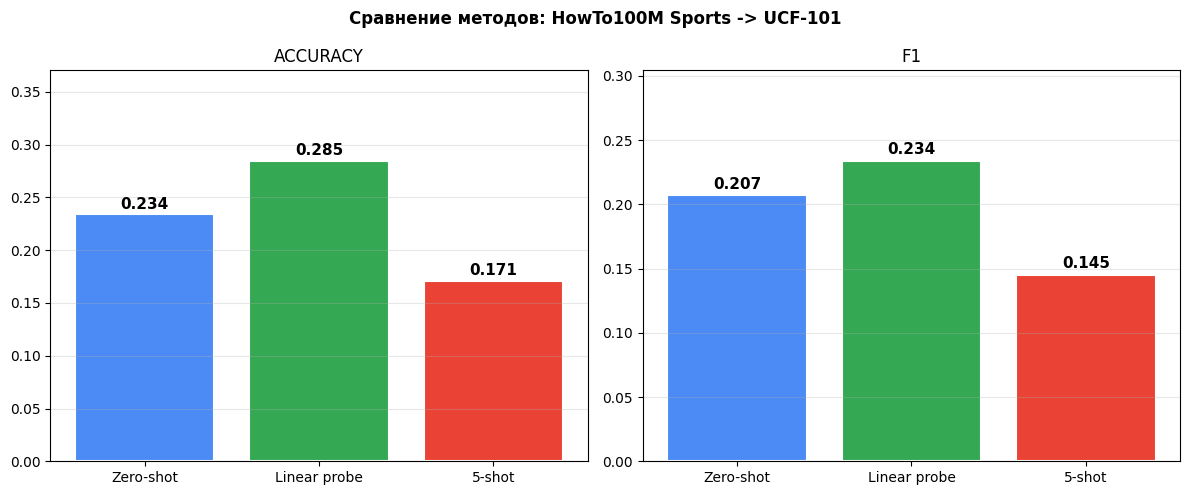

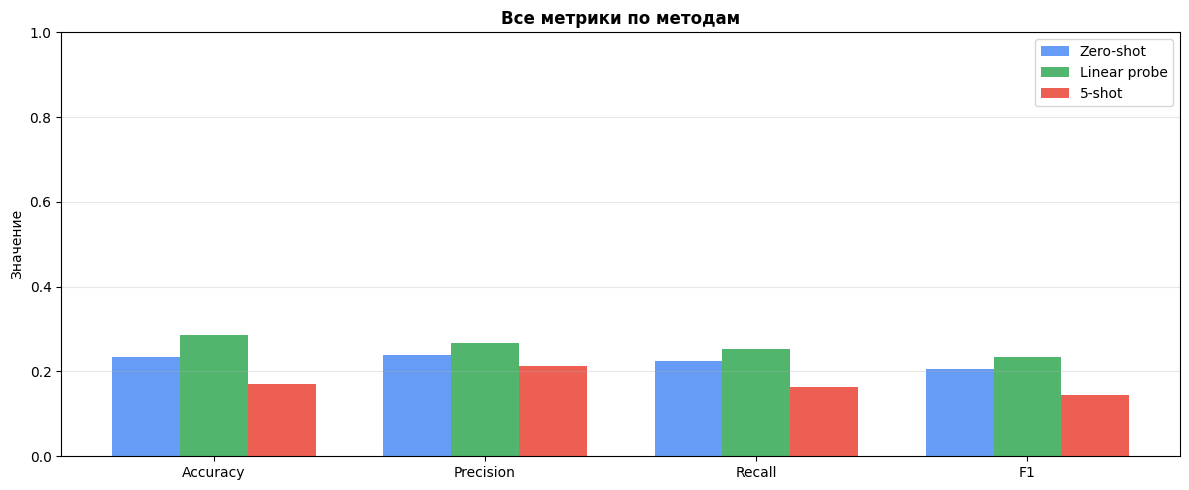

Графики сохранены на Drive


In [21]:
exp_names = ['Zero-shot', 'Linear probe', '5-shot']
colors    = ['#4C8BF5', '#34A853', '#EA4335']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Сравнение методов: HowTo100M Sports -> UCF-101',
             fontsize=12, fontweight='bold')
for ax, metric in zip(axes, ['accuracy', 'f1']):
    vals = [results[e].get(metric, 0) for e in exp_names]
    bars = ax.bar(exp_names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric.upper())
    ax.set_ylim(0, max(max(vals) * 1.3, 0.1))
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

shown = ['accuracy', 'precision', 'recall', 'f1']
x, w  = np.arange(len(shown)), 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (exp, color) in enumerate(zip(exp_names, colors)):
    vals = [results[exp].get(m, 0) for m in shown]
    ax.bar(x + i*w, vals, w, label=exp, color=color, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels([m.capitalize() for m in shown])
ax.set_ylabel('Значение')
ax.set_title('Все метрики по методам', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Графики сохранены на Drive')

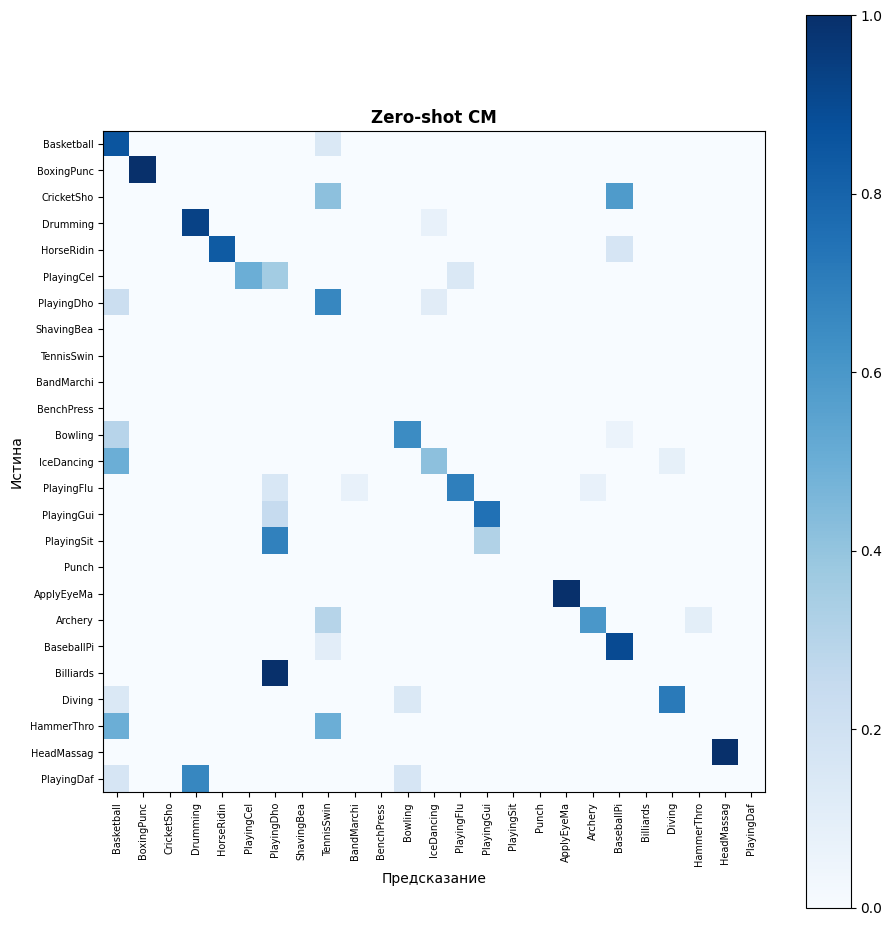

Сохранено: cm_zero-shot_cm.png


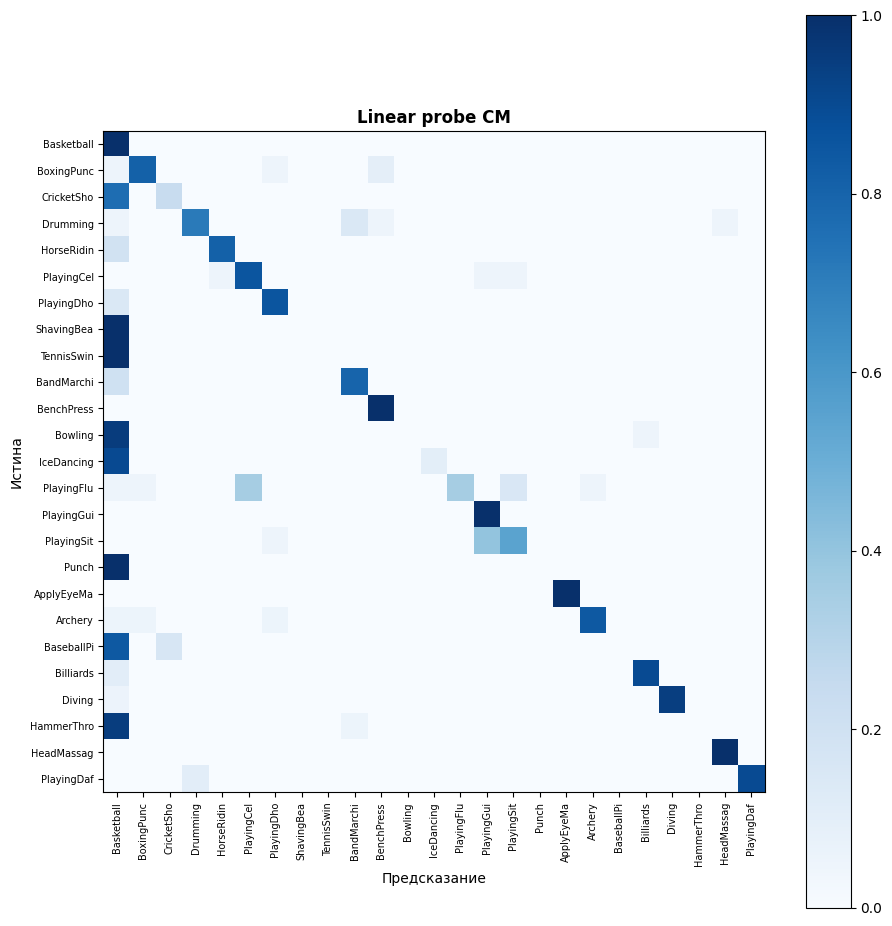

Сохранено: cm_linear_probe_cm.png


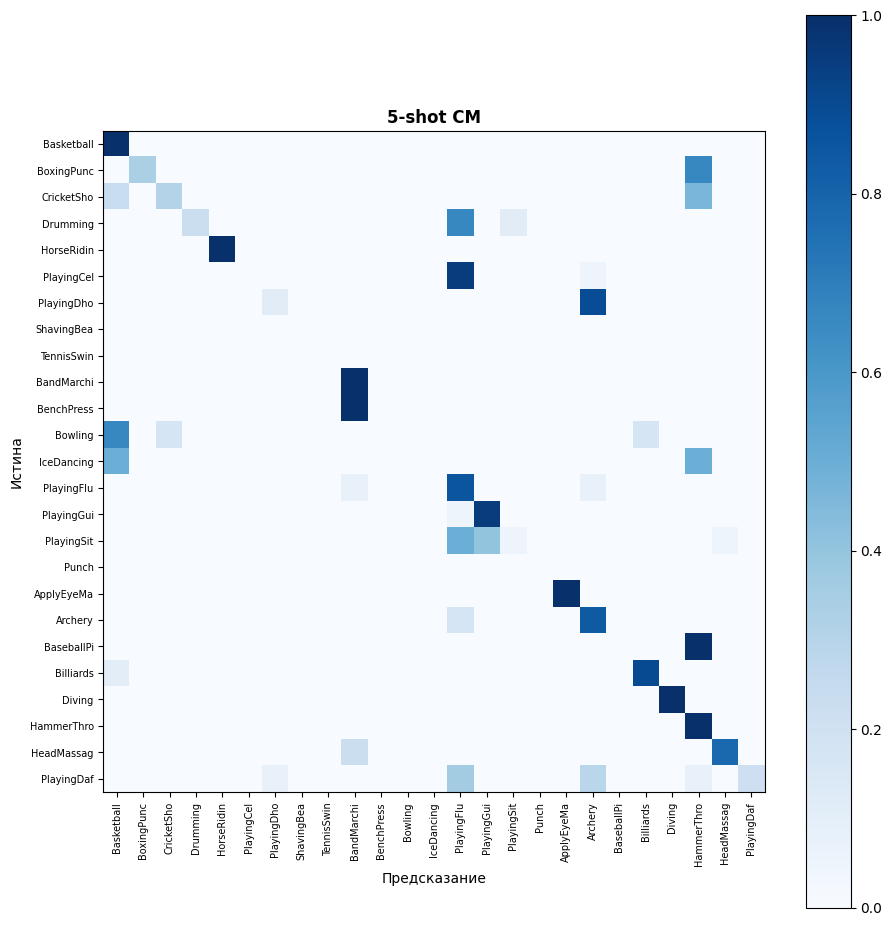

Сохранено: cm_5-shot_cm.png


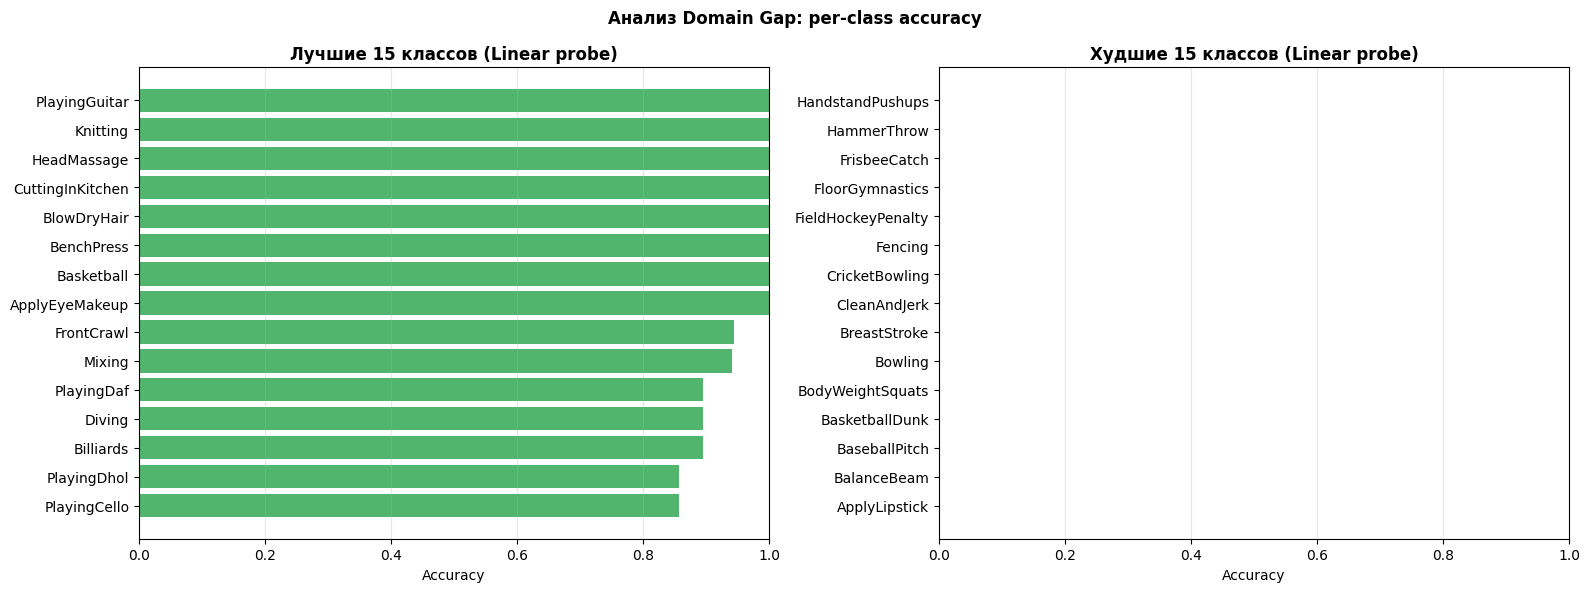

Лучшие 5 классов:
  BlowDryHair              : 1.000
  CuttingInKitchen         : 1.000
  HeadMassage              : 1.000
  Knitting                 : 1.000
  PlayingGuitar            : 1.000
Худшие 5 классов:
  ApplyLipstick            : 0.000
  BalanceBeam              : 0.000
  BaseballPitch            : 0.000
  BasketballDunk           : 0.000
  BodyWeightSquats         : 0.000


In [22]:
def plot_cm(labels, preds, class_names, title, max_cls=25):
    from collections import Counter
    top  = [c for c, _ in Counter(labels).most_common(max_cls)]
    mask = np.isin(labels, top)
    l, p = labels[mask], preds[mask]
    o2n  = {o: n for n, o in enumerate(top)}
    lr   = np.array([o2n[x] for x in l])
    pr   = np.array([o2n.get(x, -1) for x in p])
    ok   = pr >= 0
    cm   = confusion_matrix(lr[ok], pr[ok], labels=list(range(len(top))))
    cmn  = cm.astype(float) / (cm.sum(1, keepdims=True) + 1e-8)
    ticks = [class_names[i][:10] for i in top]
    sz = max(8, len(top) * 0.38)
    fig, ax = plt.subplots(figsize=(sz, sz))
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(top)))
    ax.set_yticks(range(len(top)))
    ax.set_xticklabels(ticks, rotation=90, fontsize=7)
    ax.set_yticklabels(ticks, fontsize=7)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истина')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    fname = f"{DRIVE_BASE}/cm_{title.lower().replace(' ','_').replace(':','')}.png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: {os.path.basename(fname)}')


plot_cm(test_labels, zs_preds, CLASS_NAMES, 'Zero-shot CM')
plot_cm(test_labels, lp_preds, CLASS_NAMES, 'Linear probe CM')
plot_cm(test_labels, fs_preds, CLASS_NAMES, '5-shot CM')

def per_class_acc(labels, preds, class_names):
    return {class_names[c]: (preds[labels == c] == c).mean()
            for c in np.unique(labels)}

acc_per = sorted(
    per_class_acc(test_labels, lp_preds, CLASS_NAMES).items(),
    key=lambda x: x[1]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, color, title in [
    (axes[0], acc_per[-15:], '#34A853', 'Лучшие 15 классов (Linear probe)'),
    (axes[1], acc_per[:15],  '#EA4335', 'Худшие 15 классов (Linear probe)'),
]:
    ax.barh([x[0] for x in data], [x[1] for x in data], color=color, alpha=0.85)
    ax.set_xlabel('Accuracy')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Анализ Domain Gap: per-class accuracy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/domain_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Лучшие 5 классов:')
for n, a in acc_per[-5:]: print(f'  {n:<25}: {a:.3f}')
print('Худшие 5 классов:')
for n, a in acc_per[:5]:  print(f'  {n:<25}: {a:.3f}')